Mean price is 57.88402292950034 EUR
[ 8.05017045e-01  8.50974299e-02  2.19340396e-02  8.54647813e-02
 -1.07930671e-01 -2.50261713e-03  1.04391120e-04  1.75538286e-04]
-2.5918284623636367
price_lag1:0.8050
price_lag24:0.0851
price_lag48:0.0219
price_lag168:0.0855
hour:-0.1079
month:-0.0025
total load actual:0.0001
generation fossil gas:0.0002
MAE:  1.95 EUR/MWh


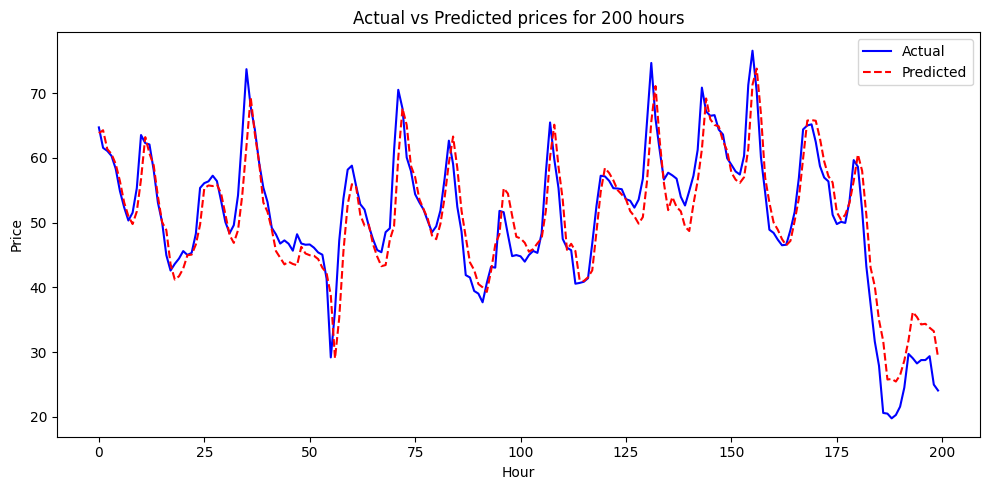

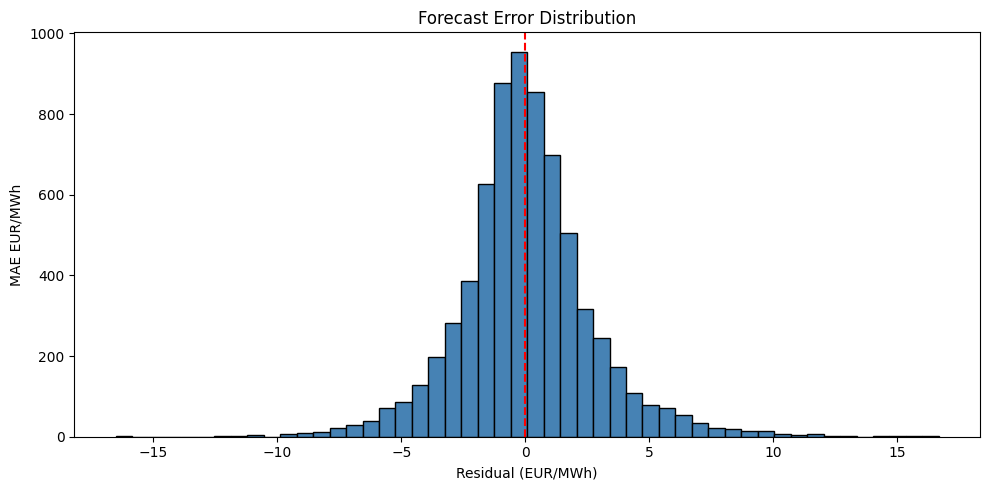

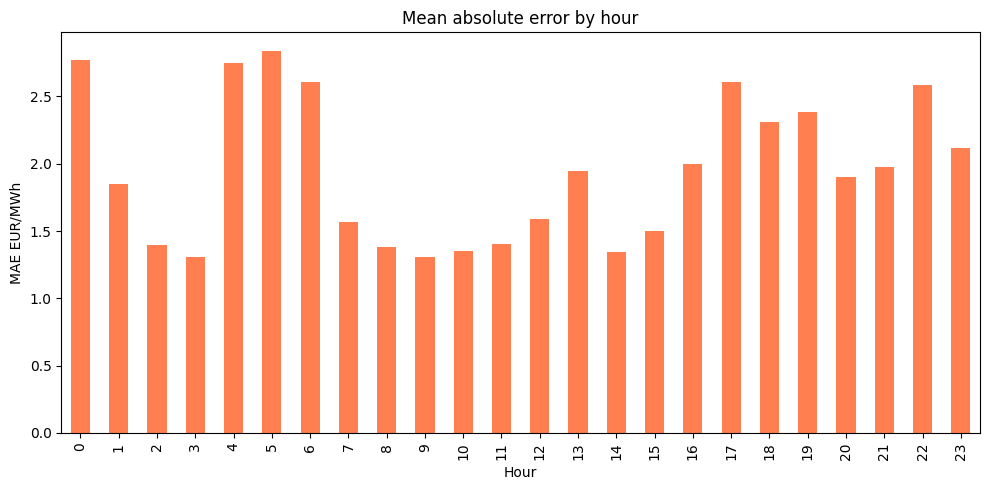

Model                            MAE   Error%
Week 1                          9.48    16.4%
Week 3 basic                    2.40     4.1%
Week 3 sequential               1.95     3.4%


In [40]:
import pandas as pd
import matplotlib.pyplot as plt

df= pd.read_csv("energy_dataset.csv") # load and clean data
df["time"] = pd.to_datetime(df["time"], utc=True) # convert rows into usable time 
df["hour"] = df["time"].dt.hour # adjusting time to hour 
df = df.set_index("time") 
df["month"] = df.index.month # adjusting time to month

df["price_lag1"] = df["price actual"].shift(1) # Shifting all data 1 row below
df["price_lag24"] = df["price actual"].shift(24) # Shifting all data 24 row below
df["price_lag48"] = df["price actual"].shift(48) # Shifting all data 48 row below
df["price_lag168"] = df["price actual"].shift(168) # Shifting all data 168 row below

mean_price = df["price actual"].mean() # looking at mean value of price
print(f"Mean price is {mean_price} EUR")

df = df[["price actual","price_lag1","price_lag24","price_lag48","price_lag168","hour","month","total load actual","generation fossil gas"]].dropna() # drops each row which have any missing value

split = int(len(df)*0.8) # Split is a variable that is calcualted by looking at number of data(rows) and multiply by where you want to split(0.8 in our case)
train = df.iloc[:split] #this creates a dataframe between the beginning and split(at 80% for our case) of df
test = df.iloc[split:] #this creates a dataframe between split(at 80% for our case) and the end of df

X_train = train[["price_lag1","price_lag24","price_lag48","price_lag168","hour","month","total load actual","generation fossil gas"]].values # we are creating variables to make a train test model
X_test = test[["price_lag1","price_lag24","price_lag48","price_lag168","hour","month","total load actual","generation fossil gas"]].values
y_train = train["price actual"].values
y_test = test["price actual"].values

from sklearn.linear_model import LinearRegression 
model = LinearRegression() # this model is basically y=mX+c in mathematical terms
model.fit(X_train,y_train)
print(model.coef_) # this is m, from the equation
print(model.intercept_) # this is c, from the equation

features = ["price_lag1","price_lag24","price_lag48","price_lag168","hour","month","total load actual","generation fossil gas"]
for feature,coef in zip(features,model.coef_):
    print(f"{feature}:{coef:.4f}") # we're mapping the variety of slope values with their respective feature

from sklearn.metrics import mean_absolute_error
y_pred = model.predict(X_test) # here we are predicting the remaining 20% data, which is trained from 80% of data
mae = mean_absolute_error(y_test,y_pred) # it calculates the mae between y_test and y_pred
print(f"MAE: {mae: .2f} EUR/MWh")

plt.figure(figsize=(10,5)) # standard plot code, done to visualize easily how close the actual and predicted values are
plt.plot(y_test[:200], color="blue")
plt.plot(y_pred[:200], color="red",linestyle="--")
plt.title("Actual vs Predicted prices for 200 hours")
plt.xlabel("Hour")
plt.ylabel("Price")
plt.legend(["Actual", "Predicted"])
plt.tight_layout()
plt.show()

residuals = y_test - y_pred # we are not looking at absolute value but creating a variable to compare how low or high our predictions are to actual

plt.figure(figsize = (10,5)) # standard plot code
plt.hist(residuals, bins=50,color="steelblue",edgecolor="black")
plt.title("Forecast Error Distribution")
plt.xlabel("Residual (EUR/MWh)")
plt.ylabel("MAE EUR/MWh")
plt.axvline(x=0, color="red",linestyle="--") # creates a line at x=0, easier to compare when predicted data overperforms or underperform
plt.tight_layout()
plt.show()

test_df = test.copy() # copying from "test" dataframe
test_df["predicted"] = y_pred
test_df["error"] = abs(test_df["price actual"] - test_df["predicted"]) # this is just mathematics, error =  actual value - predicted value
hourly_error = test_df.groupby("hour")["error"].mean()

hourly_error.plot(kind="bar", figsize=(10,5), color="coral") # standard code
plt.title("Mean absolute error by hour")
plt.xlabel("Hour")
plt.ylabel("MAE EUR/MWh")
plt.tight_layout()
plt.show()

print("="*45) # we are creating a table to look at how the model has developed over the week of my evaluation using different methods and variables
print(f"{'Model':<25} {'MAE':>10} {'Error%':>8}")
print("="*45)
print(f"{'Week 1':<25} {'9.48':>10} {'16.4%':>8}")
print(f"{'Week 3 basic':<25} {'2.40':>10} {'4.1%':>8}")
print(f"{'Week 3 sequential':<25} {f"{mae:.2f}":>10} {f"{mae/mean_price*100:.1f}%":>8}")
